# Dinâmica 01 - Do Dado ao Algoritmo (PBL)
**Unidade Curricular:** Inteligência Artificial  
**Curso:** Engenharia de Controle e Automação - Câmpus Chapecó  
**Docente:** Dra. Lara Popov Zambiasi Bazzi Oberderfer  

---
## 🎯 Objetivo da Dinâmica
Nesta atividade prática, vamos explorar como transformar dados brutos de sensores em modelos preditivos.
Trabalharemos com dois paradigmas fundamentais:
1. **Regressão Linear:** Para prever valores numéricos contínuos (Corrente).
2. **Classificação (KNN):** Para prever categorias/status de operação (Estável vs. Alerta).

# Código (Importações e Exploração)

In [1]:
# =================================================================
# 1. PREPARAÇÃO DO DATASET
# =================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

# Simulação de dados de um sistema de aquecimento industrial
data = {
    'tensao_v': [110, 120, 130, 140, 150, 160, 170, 180, 190, 200],
    'corrente_a': [1.1, 1.3, 1.5, 1.8, 2.1, 2.5, 3.0, 3.6, 4.2, 5.0],
    'status_aquecimento': [0, 0, 0, 0, 0, 0, 1, 1, 1, 1] # 0: Estável, 1: Alerta
}

df = pd.DataFrame(data)

print("--- PRIMEIRAS LINHAS DO DATASET INDUSTRIAL ---")
display(df.head())

# Dica: Para carregar um arquivo externo, usem:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('seu_arquivo.csv')

--- PRIMEIRAS LINHAS DO DATASET INDUSTRIAL ---


,tensao_v,corrente_a,status_aquecimento
0,110,1.1,0
1,120,1.3,0
2,130,1.5,0
3,140,1.8,0
4,150,2.1,0


### 📈 Sprint 1: Regressão Linear
**Problema:** Como a corrente elétrica ($A$) se comporta em relação à variação da tensão ($V$)?  
O objetivo aqui é encontrar a linha de tendência que melhor descreve essa relação física.

# Código (Implementação da Regressão)

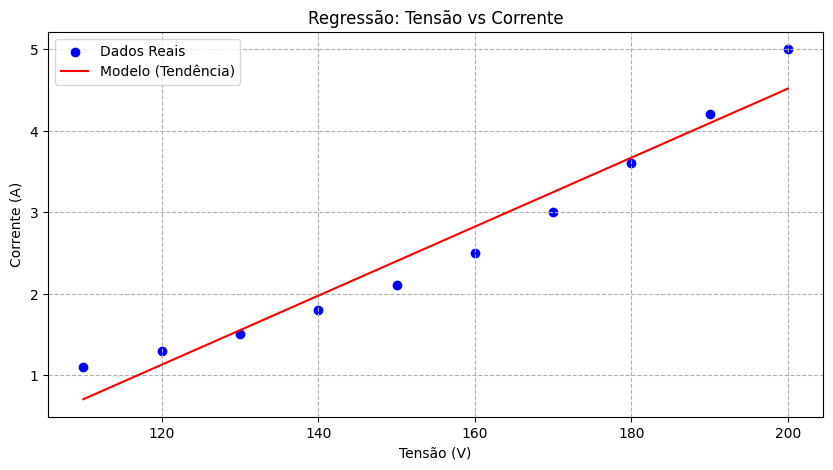

In [4]:
X = df[['tensao_v']]
y_reg = df['corrente_a']

modelo_reg = LinearRegression()
modelo_reg.fit(X, y_reg)

plt.figure(figsize=(10, 5))
plt.scatter(X, y_reg, color='blue', label='Dados Reais')
plt.plot(X, modelo_reg.predict(X), color='red', label='Modelo (Tendência)')
plt.title('Regressão: Tensão vs Corrente')
plt.xlabel('Tensão (V)')
plt.ylabel('Corrente (A)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

### 🚨 Sprint 2: Classificação (KNN)
**Problema:** O sistema entra em estado de Alerta de Aquecimento em tensões elevadas.  
Utilizaremos o algoritmo **KNN (K-Nearest Neighbors)** para classificar o status da máquina baseado na tensão lida.

In [5]:
y_clf = df['status_aquecimento']

modelo_clf = KNeighborsClassifier(n_neighbors=3)
modelo_clf.fit(X, y_clf)

# --- TESTE DE MONITORAMENTO (Ajustado para evitar UserWarning) ---
# Criamos um DataFrame para o teste para manter os nomes das colunas
teste_v = pd.DataFrame([[175]], columns=['tensao_v'])
predicao = modelo_clf.predict(teste_v)
resultado = "⚠️ ALERTA (Aquecimento)" if predicao[0] == 1 else "✅ ESTÁVEL"

print(f"--- TESTE DE MONITORAMENTO ---")
print(f"Entrada de Sensor: 175V")
print(f"Diagnóstico do Algoritmo: {resultado}")

--- TESTE DE MONITORAMENTO ---
Entrada de Sensor: 175V
Diagnóstico do Algoritmo: ⚠️ ALERTA (Aquecimento)


# 📝 Ficha de Análise: Desafio 01

1. **Sprint 1 (Regressão):** Observe a linha de tendência vermelha no gráfico. Os pontos reais seguem exatamente a linha ou existe um erro residual? O que esse erro representa em um sensor real?
2. **Sprint 2 (Classificação):** No teste de classificação para **175V**, o modelo retornou Alerta ou Estável? Baseado nos dados brutos, você concorda com essa decisão do algoritmo?
3. **Hiperparâmetros:** O que aconteceria com a classificação se mudássemos o `n_neighbors` de 3 para 1? O modelo ficaria mais ou menos sensível a ruídos?
4. **Integração de Sistemas:** Como Engenheiro(a) de Controle, como você utilizaria esses dois modelos (Regressão e Classificação) em conjunto para monitorar uma caldeira industrial?